# documentation.classical_gnns

Here we present the documentation for the modules in the `classical_gnns` subdirectory of the `qGNNs` project.

```
qGNNs
    |
    |_ classical_gnns
        |
        |_ shallow_kipf_welling_gnn.py
    |
    .
    .
    .  
```

In [1]:
import os
os.chdir('..')

## shallow_kipf_welling_gnn

This module implements a minimal classical graph neural network based on the propagation rule introduced by Kipf and Welling. It is designed as the first classical baseline of the project and integrates directly with the `GraphInput` abstraction defined in the graph utilities. The main purpose of this module is to provide a clean, modular, and easily inspectable implementation of shallow graph convolution, which can later be compared with more advanced architectures and with the quantum graph neural network variants developed in the project. This module includes
- a single Kipf–Welling graph convolution step,
- basic activation functions,
- helper functions for constructing simple weight matrices,
- one-layer and two-layer wrappers.

In [2]:
from classical_gnns.shallow_kipf_welling_gnn import *

A typical pipeline with this module is shown in the following snippets.

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from utils.graphs import build_graph_input

In [4]:
G = nx.path_graph(5)
edge_signals = {(0, 1): [0.2],(1, 2): [0.5],(2, 3): [1.0],(3, 4): [0.7],}
node_signals = [[1.0, 0.0],[0.5, 0.2],[0.0, 1.0],[0.2, 0.5],[1.0, 1.0],]
graph_input = build_graph_input(G,node_signals=node_signals,edge_signals=edge_signals,)
print("Node order:", graph_input.node_order)
print("Node signals:", graph_input.node_signals)
print("Edge signals:", graph_input.edge_signals)

A_hat = graph_input.kipf_welling_adjacency()
print("Kipf-Welling normalized adjacency:", A_hat)
W1 = build_random_weight(in_features=2,out_features=3,seed=1,scale=0.5,)
W2 = build_random_weight(in_features=3,out_features=1,seed=2,scale=0.5,)
layer1 = KipfWellingLayer(weight=W1,activation=relu,)
layer2 = KipfWellingLayer(weight=W2,activation=identity,)
H1 = layer1.forward(graph_input)
H2 = layer2.forward(graph_input, features=H1)
print("Hidden representation H1:", H1)
print("H1 shape:", H1.shape)
print("Final representation H2:", H2)
print("H2 shape:", H2.shape)

Node order: [0, 1, 2, 3, 4]
Node signals: [[1.  0. ]
 [0.5 0.2]
 [0.  1. ]
 [0.2 0.5]
 [1.  1. ]]
Edge signals: {(0, 1): array([0.2]), (1, 2): array([0.5]), (2, 3): array([1.]), (3, 4): array([0.7])}
Kipf-Welling normalized adjacency: [[0.5        0.40824829 0.         0.         0.        ]
 [0.40824829 0.33333333 0.33333333 0.         0.        ]
 [0.         0.33333333 0.33333333 0.33333333 0.        ]
 [0.         0.         0.33333333 0.33333333 0.40824829]
 [0.         0.         0.         0.40824829 0.5       ]]
Hidden representation H1: [[0.06846592 0.32622158 0.13455753]
 [0.         0.41725145 0.18426152]
 [0.         0.35237295 0.16502379]
 [0.         0.60624333 0.28117423]
 [0.         0.55768842 0.25325086]]
H1 shape: (5, 3)
Final representation H2: [[-0.11335153]
 [-0.13461242]
 [-0.16327543]
 [-0.19509884]
 [-0.18743196]]
H2 shape: (5, 1)


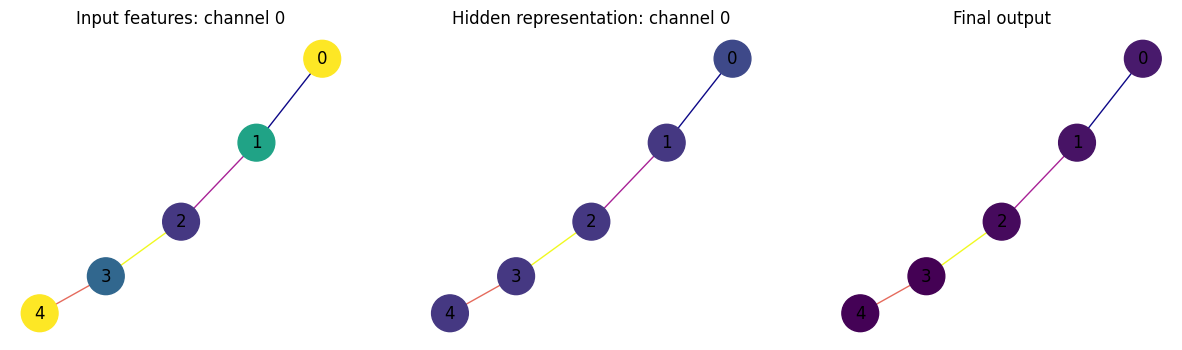

In [5]:
pos = nx.spring_layout(G, seed=42)
X = graph_input.node_signals
input_channel = X[:, 0]
hidden_channel = H1[:, 0]
output_channel = H2[:, 0]
# Edge values (take first feature)
edge_values = []
for u, v in G.edges():
    key = (u, v) if (u, v) in graph_input.edge_signals else (v, u)
    edge_values.append(graph_input.edge_signals[key][0])
all_vals = np.concatenate([input_channel, hidden_channel, output_channel])
vmin, vmax = all_vals.min(), all_vals.max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
nx.draw(G,pos,with_labels=True,node_color=input_channel,edge_color=edge_values,cmap="viridis",
        edge_cmap=plt.cm.plasma,vmin=vmin,vmax=vmax,node_size=700,ax=axes[0],)
axes[0].set_title("Input features: channel 0")
nx.draw(G,pos,with_labels=True,node_color=hidden_channel,edge_color=edge_values,cmap="viridis",
        edge_cmap=plt.cm.plasma,vmin=vmin,vmax=vmax,node_size=700,ax=axes[1],)
axes[1].set_title("Hidden representation: channel 0")
nx.draw(G,pos,with_labels=True,node_color=output_channel,edge_color=edge_values,cmap="viridis",
        edge_cmap=plt.cm.plasma,vmin=vmin,vmax=vmax,node_size=700,ax=axes[2],)
axes[2].set_title("Final output")
plt.show()

### Functions

There are different functions building different components of the network.

- `relu`: applies the Rectified Linear Unit activation function elementwise to the input array.

In [6]:
x = np.array([[-1.0, 0.5], [2.0, -0.3]])
relu(x)

array([[0. , 0.5],
       [2. , 0. ]])

- `identity`: applies the identity activation function elementwise to the input.

In [7]:
identity(x)

array([[-1. ,  0.5],
       [ 2. , -0.3]])

- `build_identity_weight`: constructs an identity weight matrix of shape `(in_features, in_features)` (input features per node). This is useful when one wants to isolate the effect of graph propagation without introducing a nontrivial learned feature transformation.

In [8]:
build_identity_weight(in_features=3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

- `build_random_weight`: constructs a random weight matrix with Gaussian entries.

In [9]:
build_random_weight(in_features=2,out_features=4,seed=7,scale=0.1,)

array([[ 1.23015336e-04,  2.98745538e-02, -2.74137855e-02,
        -8.90591839e-02],
       [-4.54670785e-02, -9.91646555e-02,  6.01436026e-03,
         1.34021525e-01]])

- `one_step_kipf_welling` : s a convenience wrapper that applies a single Kipf–Welling graph convolution step without explicitly instantiating the `KipfWellingLayer` class (see below).

In [10]:
G = nx.path_graph(4)
graph_input = build_graph_input(G,node_signals=[1.0, 0.0, 0.0, 0.0],)
W = build_identity_weight(in_features=1)
one_step_kipf_welling(graph_input=graph_input, weight=W, activation=identity,)

array([[0.5       ],
       [0.40824829],
       [0.        ],
       [0.        ]])

- `two_layer_kipf_welling` : applies a simple two-layer shallow graph neural network obtained by stacking two Kipf–Welling propagation steps.

In [11]:
G = nx.path_graph(4)
graph_input = build_graph_input(G, node_signals=[[1.0, 0.0],[0.5, 0.5],[0.0, 1.0],[1.0, 1.0]],)
W1 = build_random_weight(in_features=2, out_features=3, seed=1)
W2 = build_random_weight(in_features=3, out_features=2, seed=2)
two_layer_kipf_welling(graph_input=graph_input, weight_1=W1,weight_2=W2,hidden_activation=relu,output_activation=identity,)


array([[ 0.00281276, -0.01475606],
       [ 0.00408581, -0.02031366],
       [ 0.00510732, -0.02384292],
       [ 0.00477948, -0.0219113 ]])

### Classes

There is a single class `KipfWellingLayer`. 

#### KipfWellingLayer

This class provide a single graph convolution steps. The corresponding layer applies $H_{out}=\sigma(\hat{A}H_{in}W+b)$ where $W$ is the weight matrix, $b$ is the bias, $\hat{A}$ is the normalized adjacency matrix, and $\sigma$ is an activation function. 

**KipfWellingLayer Parameters**
- `weight` : an np.ndarray representing the weight matrix of shapoe `(F_in, F_out)` (input-output features per node).
- `bias` : an optional bias vector of shape `(F_out, )`.
- `activation` : a Callable function applying the activation function elementwise to the output. Typical choices are `relu` or `identity`.

In [12]:
KFL = KipfWellingLayer(None)
KFL 

KipfWellingLayer(weight=None, bias=None, activation=<function identity at 0x105a34860>)

**KipfWellingLayer Methods**
- `forward()`: Applies one graph convolution step returning an output feature matrix of shape `(N,F_out)`.
- validation and error handling functions (i.e., `_resolve_features`).

A typical workflow for this class is shown below.

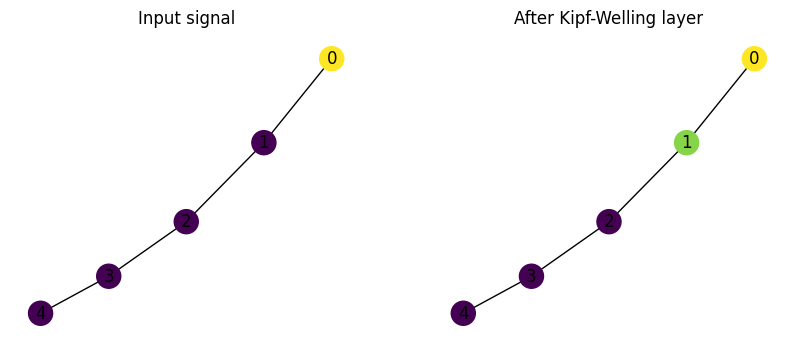

In [13]:
G = nx.path_graph(5)
signals = [1.0, 0.0, 0.0, 0.0, 0.0]
graph_input = build_graph_input(G, node_signals=signals)
W = build_identity_weight(1)
layer = KipfWellingLayer(weight=W, activation=identity)
output = layer.forward(graph_input).flatten()

pos = nx.spring_layout(G, seed=42)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
nx.draw(G, pos, node_color=signals, cmap="viridis", with_labels=True,ax=axes[0])
axes[0].set_title("Input signal")
nx.draw(G, pos,node_color=output,cmap="viridis",with_labels=True,ax=axes[1])
axes[1].set_title("After Kipf-Welling layer")
plt.show()